<a href="https://colab.research.google.com/github/aini43325018-ui/2025_algoritma_dan_pemrograman/blob/Visi-Komputer---Semester-3/Jobsheet%202%3A%20Klasifikasi%20Gambar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Praktikum D1 - Memulai Klasifikasi Gambar dengan Dataset Sederhana

In [ ]:
!pip install matplotlib

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


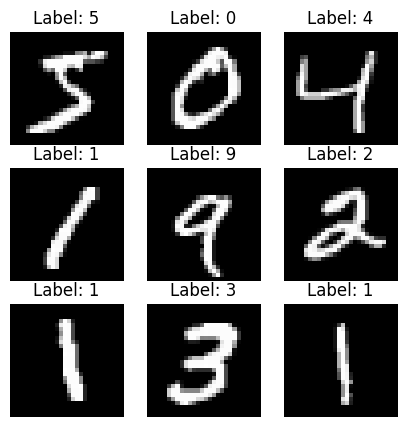

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Tampilkan contoh
plt.figure(figsize=(5,5))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(x_train[i], cmap='gray')
  plt.title(f"Label: {y_train[i]}")
  plt.axis('off')
plt.show()

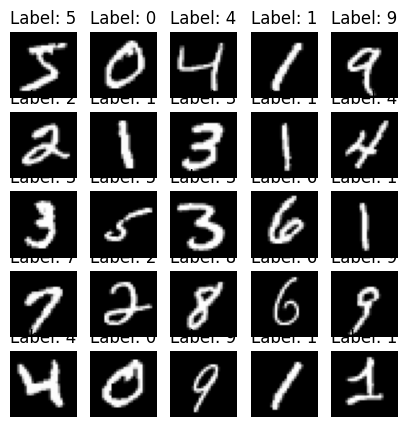

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Tampilkan contoh
plt.figure(figsize=(5,5))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.imshow(x_train[i], cmap='gray')
  plt.title(f"Label: {y_train[i]}")
  plt.axis('off')
plt.show()

Praktikum D2 - Klasifikasi Gambar dengan Model Machine Learning Tradisional

In [15]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# Flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# SVM
clf = svm.SVC(kernel='linear', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000]) # gunakan subset karena SVM berat
y_pred = clf.predict(x_test_flat)

print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.9101


In [16]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# Flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# SVM
clf = svm.SVC(kernel='rbf', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000]) # gunakan subset karena SVM berat
y_pred = clf.predict(x_test_flat)

print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.9513


Praktikum D3 - Membangun CNN Sederhana

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 64s 36ms/step - accuracy: 0.9470 - loss: 0.1791 - val_accuracy: 0.9785 - val_loss: 0.0737
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 74s 32ms/step - accuracy: 0.9814 - loss: 0.0613 - val_accuracy: 0.9850 - val_loss: 0.0539
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 55s 32ms/step - accuracy: 0.9874 - loss: 0.0417 - val_accuracy: 0.9843 - val_loss: 0.0601
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 61s 36ms/step - accuracy: 0.9902 - loss: 0.0306 - val_accuracy: 0.9863 - val_loss: 0.0467
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 56s 21ms/step - accuracy: 0.9932 - loss: 0.0213 - val_accuracy: 0.9855 - val_loss: 0.0596


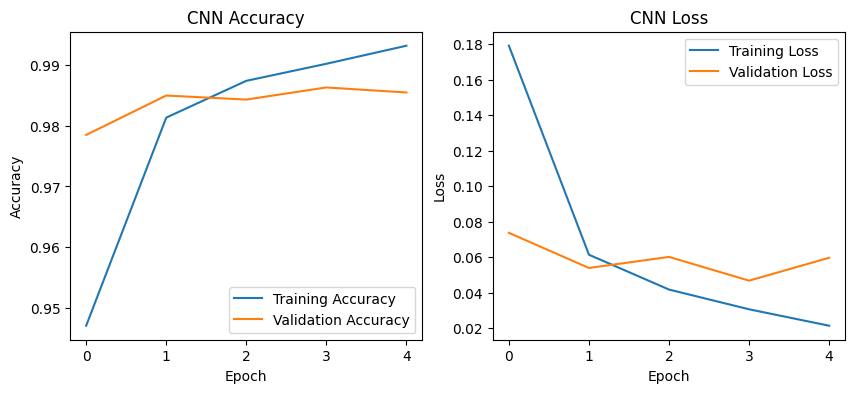

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# Memuat kembali dataset MNIST untuk memastikan variabel x_train dan x_test berisi data 28x28
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Melakukan reshape dan normalisasi untuk MNIST
x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation ='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

# Plot History
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 59s 34ms/step - accuracy: 0.9602 - loss: 0.1337 - val_accuracy: 0.9832 - val_loss: 0.0587
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 33ms/step - accuracy: 0.9866 - loss: 0.0450 - val_accuracy: 0.9868 - val_loss: 0.0438
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 57s 34ms/step - accuracy: 0.9911 - loss: 0.0280 - val_accuracy: 0.9898 - val_loss: 0.0421
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 34ms/step - accuracy: 0.9934 - loss: 0.0199 - val_accuracy: 0.9892 - val_loss: 0.0418
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 33ms/step - accuracy: 0.9950 - loss: 0.0154 - val_accuracy: 0.9883 - val_loss: 0.0511


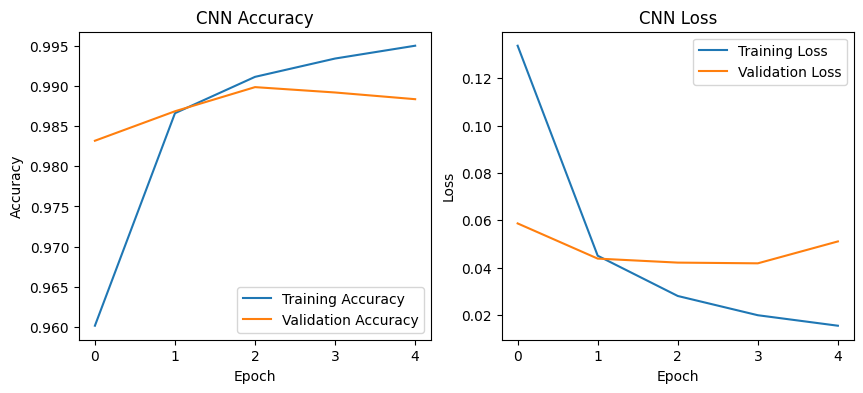

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation ='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

# Plot History
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Praktikum D4 - Eksperimen dengan Dataset Lebih Kompleks (CIFAR-10)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 64s 44ms/step - accuracy: 0.4587 - loss: 1.5041 - val_accuracy: 0.5428 - val_loss: 1.2590
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 62s 44ms/step - accuracy: 0.5975 - loss: 1.1444 - val_accuracy: 0.6294 - val_loss: 1.0469
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 42ms/step - accuracy: 0.6484 - loss: 1.0104 - val_accuracy: 0.6368 - val_loss: 1.0551
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 43ms/step - accuracy: 0.6780 - loss: 0.9266 - val_accuracy: 0.6584 - val_loss: 0.9847
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 41ms/step - accuracy: 0.7001 - loss: 0.8599 - val_accuracy: 0.6792 - val_loss: 0.9297
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 60s 42ms/step - accuracy: 0.7194 - loss: 0.8056 - val_accuracy: 0.6946 - val_loss: 0.9104
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 59s 42ms/step - accuracy: 0.7398 - loss: 0.7504 - val_accuracy: 0.6980 - val_loss: 0.8735
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 43ms/step - accuracy: 0.7545 -

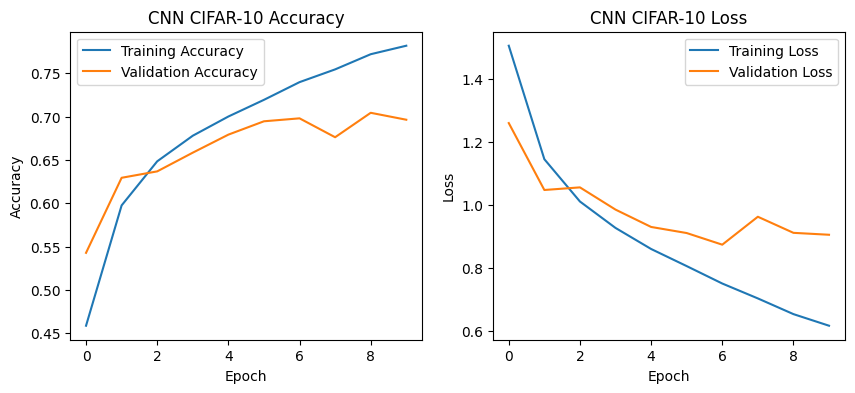

In [ ]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation ='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_split=0.1)

# Plot History
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1592s 9us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 46ms/step - accuracy: 0.3645 - loss: 1.7322 - val_accuracy: 0.5294 - val_loss: 1.3364
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 78s 43ms/step - accuracy: 0.4902 - loss: 1.4222 - val_accuracy: 0.5880 - val_loss: 1.1814
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 59s 42ms/step - accuracy: 0.5337 - loss: 1.3023 - val_accuracy: 0.6278 - val_loss: 1.0803
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 60s 42ms/step - accuracy: 0.5625 - loss: 1.2307 - val_accuracy: 0.6278 - val_loss: 1.0799
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 58s 41ms/step - accuracy: 0.5837 - loss: 1.1696 - val_accuracy: 0.6448 - val_loss: 1.0193
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 60s 43ms/step - accuracy: 0.6022 - loss: 1.1202 - val_accuracy: 0.6628 - val_loss: 0.9643
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 42ms/step - accuracy: 0.6180 - loss: 1.0818 - val_accuracy: 0.6814 - val_loss: 0.9279
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.6273 -

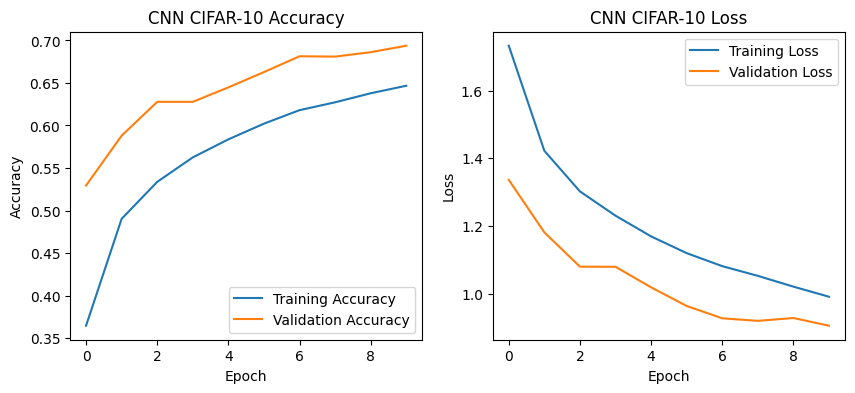

In [ ]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation ='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_split=0.1)

# Plot History
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Praktikum D5 - Transfer Learning dengan Model Pra-Latih

In [3]:
from tensorflow.keras.datasets import cifar10

# 1. Memuat dataset CIFAR-10 ke dalam variabel
print("Memuat dataset CIFAR-10...")
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 2. Normalisasi data gambar (mengubah nilai pixel dari 0-255 menjadi 0-1)
# Ini penting agar model bisa belajar dengan lebih baik
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Dataset berhasil dimuat dan dinormalisasi!")
print("Bentuk x_train:", x_train.shape)
print("Bentuk y_train:", y_train.shape)

Memuat dataset CIFAR-10...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Dataset berhasil dimuat dan dinormalisasi!
Bentuk x_train: (50000, 32, 32, 3)
Bentuk y_train: (50000, 1)


Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 628s 446ms/step - accuracy: 0.5152 - loss: 1.3873 - val_accuracy: 0.5754 - val_loss: 1.2309
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 695s 455ms/step - accuracy: 0.5806 - loss: 1.1987 - val_accuracy: 0.5940 - val_loss: 1.1614
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 638s 454ms/step - accuracy: 0.6010 - loss: 1.1376 - val_accuracy: 0.6088 - val_loss: 1.1285
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 644s 458ms/step - accuracy: 0.6179 - loss: 1.0978 - val_accuracy: 0.6062 - val_loss: 1.1228
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 645s 458ms/step - accuracy: 0.6282 - loss: 1.0671 - val_accuracy: 0.6042 - val_loss: 1.1221


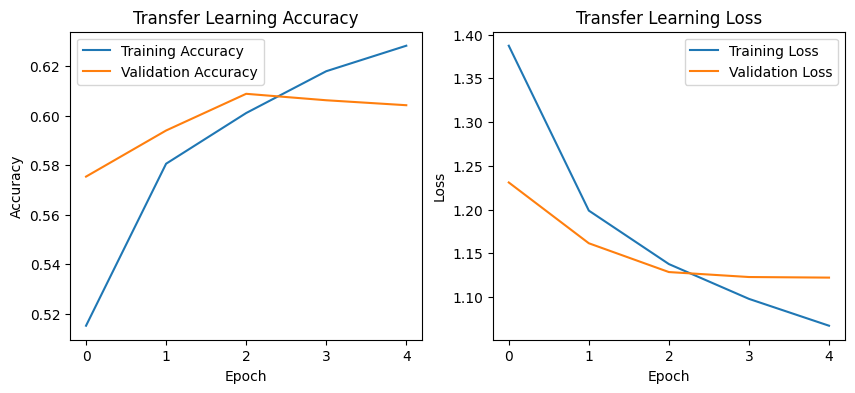

In [5]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

# Memuat model VGG16 tanpa layer klasifikasi atas (include_top=False)
base_model = VGG16(weights='imagenet',
                   include_top=False, input_shape=(32,32,3))

# Membekukan seluruh layer convolutional pada VGG16
base_model.trainable = False

# Membuat model klasifikasi baru
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Mengkompilasi model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Melatih model (hanya layer Dense yang dilatih)
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# ----- Plot history -----
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 749s 529ms/step - accuracy: 0.5630 - loss: 1.2522 - val_accuracy: 0.6310 - val_loss: 1.0737
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 780s 514ms/step - accuracy: 0.6331 - loss: 1.0506 - val_accuracy: 0.6124 - val_loss: 1.0884
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 736s 510ms/step - accuracy: 0.6577 - loss: 0.9808 - val_accuracy: 0.6476 - val_loss: 1.0073
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 716s 509ms/step - accuracy: 0.6738 - loss: 0.9266 - val_accuracy: 0.6496 - val_loss: 1.0261
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 812s 559ms/step - accuracy: 0.6886 - loss: 0.8815 - val_accuracy: 0.6716 - val_loss: 0.9529


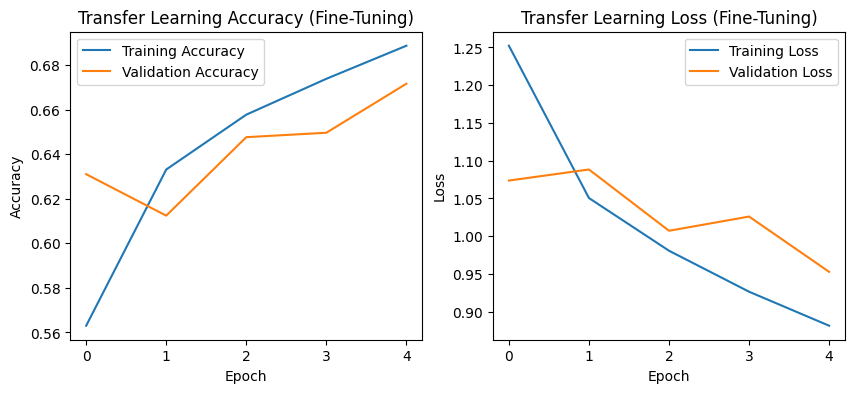

In [6]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))


base_model.trainable = True
for layer in base_model.layers[:-2]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy (Fine-Tuning)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss (Fine-Tuning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Praktikum D6 - Evaluasi dengan Confusion Matrix dan Metrik Lain

313/313 ━━━━━━━━━━━━━━━━━━━━ 123s 392ms/step
              precision    recall  f1-score   support

           0       0.78      0.64      0.70      1000
           1       0.78      0.72      0.75      1000
           2       0.67      0.50      0.58      1000
           3       0.48      0.54      0.51      1000
           4       0.50      0.72      0.59      1000
           5       0.61      0.49      0.55      1000
           6       0.66      0.70      0.68      1000
           7       0.72      0.73      0.73      1000
           8       0.74      0.81      0.77      1000
           9       0.74      0.72      0.73      1000

    accuracy                           0.66     10000
   macro avg       0.67      0.66      0.66     10000
weighted avg       0.67      0.66      0.66     10000



Text(70.72222222222221, 0.5, 'True')

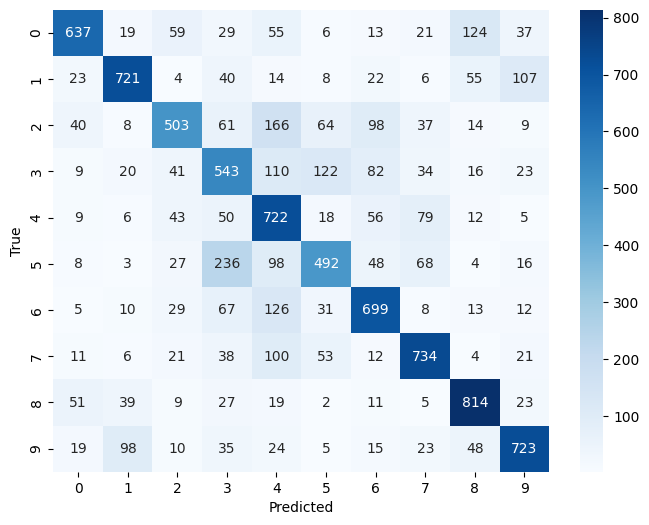

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(x_test).argmax(axis=1)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')

313/313 ━━━━━━━━━━━━━━━━━━━━ 122s 389ms/step
              precision    recall  f1-score   support

           0       0.78      0.64      0.70      1000
           1       0.78      0.72      0.75      1000
           2       0.67      0.50      0.58      1000
           3       0.48      0.54      0.51      1000
           4       0.50      0.72      0.59      1000
           5       0.61      0.49      0.55      1000
           6       0.66      0.70      0.68      1000
           7       0.72      0.73      0.73      1000
           8       0.74      0.81      0.77      1000
           9       0.74      0.72      0.73      1000

    accuracy                           0.66     10000
   macro avg       0.67      0.66      0.66     10000
weighted avg       0.67      0.66      0.66     10000



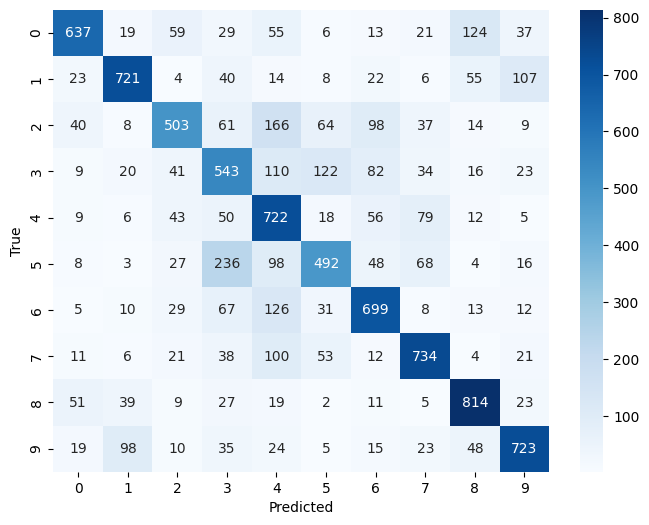

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(x_test).argmax(axis=1)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Penugasan

In [9]:
from google.colab import files
uploaded = files.upload() # pilih 1 atau lebih file gambar (jpg/png)

import numpy as np
from PIL import Image, ImageOps

def preprocess_to_mnist_28x28(img_pil):
    """
    Langkah:
    - Konversi ke grayscale
    - Auto-contrast
    - (Opsional) invert bila latar terang (agar digit jadi putih, latar jadi gelap seperti MNIST)
    - Crop ke bounding box digit
    - Resize mempertahankan rasio ke (20x20), lalu pad ke (28x28)
    - Normalisasi ke [0,1] dan tambah axis channel
    """
    # Grayscale + autocontrast
    img = img_pil.convert('L')
    img = ImageOps.autocontrast(img)

    arr = np.array(img).astype(np.uint8)
    # Jika rata-rata terang (kertas putih), invert supaya digit menjadi putih di atas latar gelap (gaya MNIST)
    if arr.mean() > 127:
        img = ImageOps.invert(img)
    arr = np.array(img)

    # Binarisasi ringan untuk cari bbox digit
    thr = np.mean(arr) * 0.8 # ambang adaptif sederhana
    mask = arr > thr
    if mask.any():
        ys, xs = np.where(mask)
        y0, y1 = ys.min(), ys.max()
        x0, x1 = xs.min(), xs.max()
        img = img.crop((x0, y0, x1+1, y1+1))

    # Resize ke 20x20 dengan aspect ratio
    img.thumbnail((20, 20), Image.Resampling.LANCZOS)
    w, h = img.size

    # Pad ke 28x28 dan center
    canvas = Image.new('L', (28, 28), color=0)
    canvas.paste(img, ((28 - w)//2, (28 - h)//2))

    # Normalisasi ke [0,1]
    arr = np.array(canvas).astype('float32') / 255.0
    # Tambah channel dim (28,28,1)
    arr = arr[..., None]
    return canvas, arr

Saving lapan.jpeg to lapan.jpeg
Saving dua.jpeg to dua.jpeg
Saving satu.jpeg to satu.jpeg


Penugasan: Prediksi dengan CNN

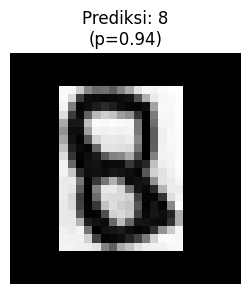

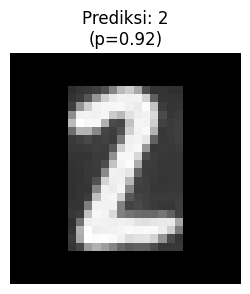

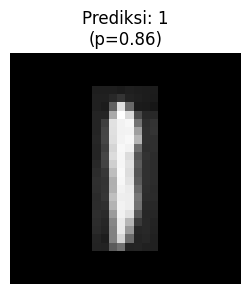

Rekap Prediksi (CNN):
- lapan.jpeg -> 8 (p=0.936)
- dua.jpeg -> 2 (p=0.919)
- satu.jpeg -> 1 (p=0.855)


In [13]:
import matplotlib.pyplot as plt
results = []
for fname in uploaded.keys():
    img_pil = Image.open(fname)
    disp, x = preprocess_to_mnist_28x28(img_pil) # disp: PIL untuk ditampilkan, x: (28,28,1)
    x_batch = np.expand_dims(x, axis=0) # (1,28,28,1)
    probs = model.predict(x_batch, verbose=0)[0] # shape (10,)
    pred = int(np.argmax(probs))
    conf = float(np.max(probs))

    results.append((fname, pred, conf))

    plt.figure(figsize=(3,3))
    plt.imshow(disp, cmap='gray')
    plt.title(f"Prediksi: {pred}\n(p={conf:.2f})")
    plt.axis('off')
    plt.show()

print("Rekap Prediksi (CNN):")
for r in results:
    print(f"- {r[0]} -> {r[1]} (p={r[2]:.3f})")

Penugasan: Prediksi dengan SVM

In [17]:
from sklearn.metrics import accuracy_score
results = []
for fname in uploaded.keys():
    img_pil = Image.open(fname)
    _, x = preprocess_to_mnist_28x28(img_pil) # x: (28,28,1) float [0,1]
    x_flat = x.reshape(1, -1) # (1,784)

    pred = int(clf.predict(x_flat)[0])

    # SVM default tidak punya proba kecuali SVC(probability=True). Jika Anda ingin probabilitas:
    # clf = svm.SVC(kernel='rbf', gamma='scale', probability=True) saat pelatihan.
    conf = None
    try:
        if hasattr(clf, "predict_proba"):
            conf = float(np.max(clf.predict_proba(x_flat)))
    except Exception:
        pass

    results.append((fname, pred, conf))

    # Tampilkan hasil (gunakan gambar 28x28 yang sudah diproses di tahap CNN juga boleh)
    print(f"{fname} -> Prediksi SVM: {pred}" + (f" (p={conf:.2f})" if conf is not None else ""))

lapan.jpeg -> Prediksi SVM: 2
dua.jpeg -> Prediksi SVM: 2
satu.jpeg -> Prediksi SVM: 1
